# Week 4: Vector Power-Up & Raster Integration

**Student Worksheet** — Fill in the code cells using AI assistance or your own code.

This week you will:
1. Master vector aggregation (dissolve & groupby)
2. Understand raster data as NumPy arrays with spatial metadata
3. Compute terrain slope from DEM
4. Extract raster values into vector shapes (zonal statistics)

**Packages needed:** `geopandas`, `rioxarray`, `rasterstats`, `numpy`, `matplotlib`

> If you haven't installed them yet, run:  
> `pip install rioxarray rasterstats geopandas folium mapclassify matplotlib`

## Cell [1] — Environment Setup

Import all necessary packages and load Week 3 township data.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr


from urllib.parse import quote

# TGOS URL
TGOS_BASE = "https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/"
url = TGOS_BASE + quote("鄉(鎮、市、區)界線1140318.zip")

# Load township boundaries
town = gpd.read_file(url, layer="TOWN_MOI_1140318")

# Convert CRS to TWD97 / TM2 zone 121 (EPSG:3826)
town = town.to_crs(epsg=3826)

# Print shape, CRS, and first 5 rows
print("Shape:", town.shape)
print("CRS:", town.crs)
print(town.head())


c:\Users\vicky\anaconda3\envs\gis\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Shape: (368, 8)
CRS: EPSG:3826
  TOWNID  TOWNCODE COUNTYNAME TOWNNAME             TOWNENG COUNTYID  \
0    V02  10014020        臺東縣      成功鎮  Chenggong Township        V   
1    T21  10013210        屏東縣      佳冬鄉    Jiadong Township        T   
2    P13  10009130        雲林縣      麥寮鄉    Mailiao Township        P   
3    V11  10014110        臺東縣      綠島鄉      Lüdao Township        V   
4    V16  10014160        臺東縣      蘭嶼鄉      Lanyu Township        V   

  COUNTYCODE                                           geometry  
0      10014  POLYGON ((286994.568 2569686.978, 287066.318 2...  
1      10013  POLYGON ((203528.677 2484633.419, 203536.121 2...  
2      10009  POLYGON ((178880.906 2634847.772, 178880.637 2...  
3      10014  MULTIPOLYGON (((300508.457 2508651.739, 300539...  
4      10014  MULTIPOLYGON (((313194.739 2427361.112, 313146...  


## Cell [2] — Dissolve & Groupby

**Dissolve**: Merge 368 townships → ~22 counties  
**Groupby**: Count shelters per county and sum capacity

1. Dissolve townships by 'COUNTYNAME' → counties GeoDataFrame
2. Print: how many counties? What geometry types?
3. Calculate area in km² for each county
4. Show the top 5 largest counties

In [ ]:
# Dissolve by COUNTYNAME
counties = town.dissolve(by='COUNTYNAME')

# Print number of counties and geometry types
print(f"Number of counties: {len(counties)}")
print(f"Geometry types: {counties.geometry.type.unique()}")

# Calculate area in km²
counties['area_km2'] = counties.area / 1000000

# Show top 5 largest counties
print("\nTop 5 largest counties:")

# 在 dissolve(by="COUNTYNAME") 之後，COUNTYNAME 已經變成 index（索引）了，不再是欄位，counties[['COUNTYNAME', 'area_km2']] 會報錯
print(counties[['area_km2']].sort_values('area_km2', ascending=False).head())

Number of counties: 22
Geometry types: <StringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str

Top 5 largest counties:
               area_km2
COUNTYNAME             
花蓮縣         4605.284306
南投縣         4097.729914
臺東縣         3582.210917
高雄市         2998.488305
屏東縣         2805.036755


---

## 🔬 Lab 1: Vector Aggregation (20 minutes)

**Goal**: Practice dissolve & groupby before entering the raster world.

> **⚠️ 注意**：Lab 1 使用**合成資料**（synthetic data）練習 dissolve/groupby 操作。課後作業（ARIA v2.0）會使用**真實的避難收容所 CSV**，操作方式相同但資料來源不同。

### Step 1: Dissolve townships → counties

1. Dissolve all townships into counties using COUNTYNAME
2. Verify: pick Hualien County (花蓮縣) and check its geometry type and area

In [ ]:
# Filter for 花蓮縣
hualien = counties.loc[["花蓮縣"]]

# Geometry type
geom_type = hualien.geometry.iloc[0].geom_type

# Area in km² (EPSG:3826 uses meters, so convert m² → km²)
area_km2 = hualien.geometry.area.iloc[0] / 1e6

print("Geometry type:", geom_type)
print("Area (km²):", area_km2)


Geometry type: Polygon
Area (km²): 4605.2843063945975


### Step 2: Create synthetic shelter data for Hualien
1. Create synthetic shelter points in Hualien County
2. Each town should have 2-8 shelters with random capacity (50-500)
3. Place shelters at each town's centroid (simplified)

In [8]:
# Filter townships for 花蓮縣
hualien_towns = town[town["COUNTYNAME"] == "花蓮縣"].copy()

# Set random seed for reproducibility
np.random.seed(42)

shelter_records = []

for idx, row in hualien_towns.iterrows():
    town_name = row["TOWNNAME"]
    centroid = row.geometry.centroid
    
    # Random number of shelters (2–8)
    n_shelters = np.random.randint(2, 9)
    
    for i in range(n_shelters):
        capacity = np.random.randint(50, 501)
        
        shelter_records.append({
            "shelter_id": f"{town_name}_{i+1}",
            "TOWNNAME": town_name,
            "capacity": capacity,
            "geometry": centroid
        })

# Create GeoDataFrame
shelters = gpd.GeoDataFrame(shelter_records, crs="EPSG:3826")

# Preview
print(shelters.head())
print("CRS:", shelters.crs)


  shelter_id TOWNNAME  capacity                        geometry
0      光復鄉_1      光復鄉       485  POINT (294406.293 2615944.762)
1      光復鄉_2      光復鄉       398  POINT (294406.293 2615944.762)
2      光復鄉_3      光復鄉       320  POINT (294406.293 2615944.762)
3      光復鄉_4      光復鄉       156  POINT (294406.293 2615944.762)
4      光復鄉_5      光復鄉       121  POINT (294406.293 2615944.762)
CRS: EPSG:3826


### Step 3: Groupby — Statistics per town
1. Group shelters by TOWNNAME
2. Calculate: count, total capacity, average capacity
3. Sort by total capacity descending

In [9]:
# Group by TOWNNAME and calculate statistics
town_stats = (
    shelters.groupby("TOWNNAME")
    .agg(
        shelter_count=("shelter_id", "count"),
        total_capacity=("capacity", "sum"),
        avg_capacity=("capacity", "mean")
    )
    .sort_values("total_capacity", ascending=False)
)

# Display all rows
print(town_stats)


          shelter_count  total_capacity  avg_capacity
TOWNNAME                                             
卓溪鄉                   8            2363    295.375000
花蓮市                   8            1990    248.750000
光復鄉                   8            1940    242.500000
萬榮鄉                   5            1609    321.800000
富里鄉                   6            1496    249.333333
玉里鎮                   6            1341    223.500000
吉安鄉                   3            1199    399.666667
壽豐鄉                   3            1060    353.333333
鳳林鎮                   3             946    315.333333
新城鄉                   3             811    270.333333
瑞穗鄉                   3             781    260.333333
豐濱鄉                   2             536    268.000000
秀林鄉                   2             434    217.000000


### Step 4: Merge stats back to geometry & visualize
1. Merge the groupby statistics back to the Hualien township geometry
2. Create an interactive map with .explore() showing total_capacity by color
3. Save the map as HTML (for Windsurf/VS Code users)


> Merge my town_summary DataFrame back into the Hualien townships GeoDataFrame
 using TOWNNAME. Then create an .explore() map colored by total_capacity
 using 'YlOrRd' colormap. Add tooltip showing TOWNNAME, shelter_count, total_capacity.
 Remember to convert to EPSG:4326 for .explore().
 Also save the map as 'outputs/lab1_hualien_capacity.html' using m.save().


In [ ]:
# Merge town summary back to Hualien townships
hualien_towns_merged = hualien_towns.merge(
    town_stats,
    on="TOWNNAME",
    how="left"
)

# Convert CRS to EPSG:4326 for explore()
hualien_towns_merged = hualien_towns_merged.to_crs(epsg=4326)

# Create interactive map
m = hualien_towns_merged.explore(
    column="total_capacity",
    cmap="YlOrRd",
    tooltip=["TOWNNAME", "shelter_count", "total_capacity"]
)

# Save map to HTML
import os
os.makedirs("outputs", exist_ok=True)

m.save("/outputs/lab1_hualien_capacity.html")



---

## Cell [3] — The Raster Glass Box: It's Just a Matrix

A raster (like a DEM) is a **NumPy array with a GPS**. Each pixel = one numeric value.

1. Create a synthetic 100x80 DEM with rioxarray
2. Use valley profile: low center, mountains on sides
3. Set CRS to EPSG:3826
4. Print: shape, CRS, resolution, min/max elevation, top-left 5x5 values

In [11]:
# Grid size
nx, ny = 100, 80

# Create normalized coordinates (0–1)
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)

X, Y = np.meshgrid(x, y)

# Elevation formula (valley: low center, high sides)
Z = 50 + 800*(2*X - 1)**2 + 200*Y + 30*np.sin(8*X)*np.cos(6*Y)

# Define spatial bounds
xmin, xmax = 302000, 303600
ymin, ymax = 2638000, 2640000

# Create real-world coordinate arrays
x_coords = np.linspace(xmin, xmax, nx)
y_coords = np.linspace(ymax, ymin, ny) 

# Wrap as xarray DataArray
dem = xr.DataArray(
    Z,
    coords={"y": y_coords, "x": x_coords},
    dims=("y", "x"),
    name="elevation"
)

# Attach CRS using rioxarray
dem = dem.rio.write_crs("EPSG:3826")

# Print required info
print("Shape:", dem.shape)
print("CRS:", dem.rio.crs)
print("Resolution:", dem.rio.resolution())
print("Min:", float(dem.min()))
print("Max:", float(dem.max()))

# Top-left 5x5 pixels
print("\nTop-left 5x5 values:")
print(dem.values[:5, :5])

Shape: (80, 100)
CRS: EPSG:3826
Resolution: (16.161616161616163, -25.31645569620253)
Min: 25.826058558849837
Max: 1078.4985717378083

Top-left 5x5 values:
[[850.         820.4248699  791.48693004 763.17047923 735.46002188]
 [852.53164557 822.94953454 794.00465932 765.68136397 737.96419758]
 [855.06329114 825.46027759 796.49463627 768.15084676 740.41359191]
 [857.59493671 827.95721956 798.95710112 770.579286   742.8086791 ]
 [860.12658228 830.44056053 801.39245275 772.96727673 745.15024649]]


## Cell [4] — Affine Transform

How does `Matrix[row, col]` become real-world `(X, Y)` coordinates?

1. Read the affine transform from your DEM
2. Print the 6 parameters and explain what each means
3. Manually convert pixel [5, 10] to real-world coordinates

>  "Get the affine transform from my DEM (dem.rio.transform()).
  Print each of the 6 parameters with labels (pixel width, rotation, top-left coords).
  Then manually compute the real-world coordinates of pixel [5, 10]
  using: real_x = a*col + b*row + c, real_y = d*col + e*row + f.
  Also print the elevation value at that pixel."

In [12]:
# Get affine transform
transform = dem.rio.transform()

# Extract 6 affine parameters
a, b, c, d, e, f = transform[:6]

print("Affine transform:", transform)
print("a (pixel width):", a)
print("b (row rotation):", b)
print("c (top-left x):", c)
print("d (column rotation):", d)
print("e (pixel height):", e)
print("f (top-left y):", f)

# Pixel indices: row=5, col=10
row, col = 5, 10

# Manually compute real-world coordinates
real_x = a * col + b * row + c
real_y = d * col + e * row + f

print("\nPixel [5, 10]")
print("Real-world x:", real_x)
print("Real-world y:", real_y)

# Elevation value at that pixel
elevation = dem.values[row, col]
print("Elevation:", elevation)


Affine transform: | 16.16, 0.00, 301991.92|
| 0.00,-25.32, 2640012.66|
| 0.00, 0.00, 1.00|
a (pixel width): 16.161616161616163
b (row rotation): 0.0
c (top-left x): 301991.9191919192
d (column rotation): 0.0
e (pixel height): -25.31645569620253
f (top-left y): 2640012.658227848

Pixel [5, 10]
Real-world x: 302153.5353535354
Real-world y: 2639886.0759493667
Elevation: 592.2193631709488


## Cell [5] — DEM Visualization

Create a side-by-side plot: elevation + hillshade.
1. Create a 1x2 subplot: left = elevation with 'terrain' colormap, right = hillshade
2. Save as outputs/cell5_dem.png

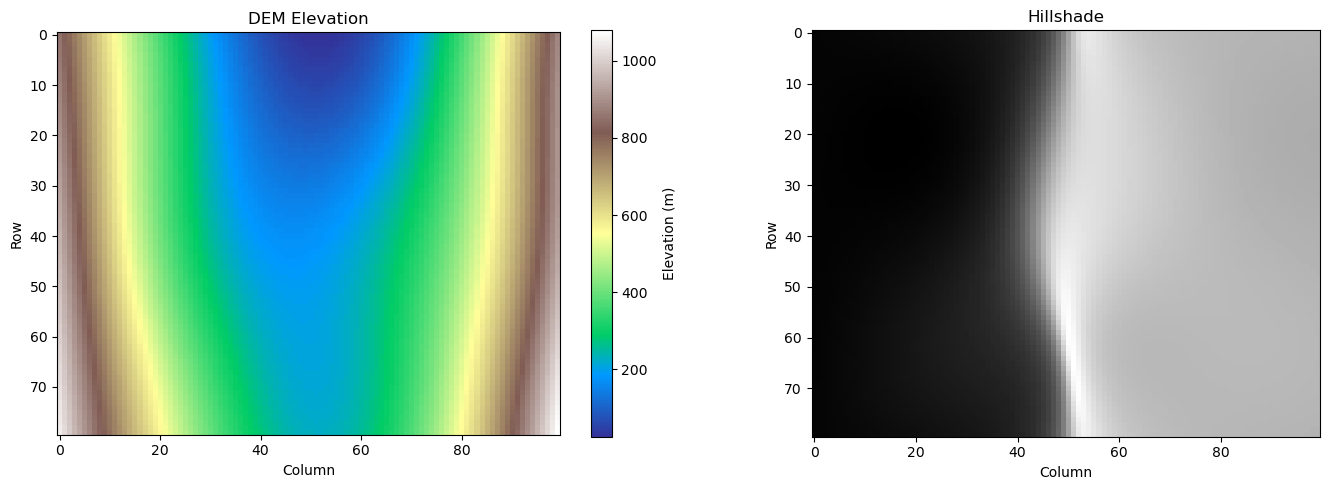

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# Create output folder
os.makedirs("outputs", exist_ok=True)

# Create 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: DEM elevation
im = axes[0].imshow(dem.values, cmap="terrain", origin="upper")
axes[0].set_title("DEM Elevation")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Elevation (m)")

# Right: hillshade
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem.values)
axes[1].imshow(hillshade, cmap="gray", origin="upper")
axes[1].set_title("Hillshade")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")

# Save figure
plt.tight_layout()
plt.savefig("/outputs/cell5_dem.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 🔬 Lab 2: Raster Exploration on Colab (15 minutes)

### ⚡ 請選擇你的環境：

| | **Option A: Google Colab（建議）** | **Option B: 本機 fallback** |
|---|---|---|
| 適用情境 | 網路正常、Drive mount 成功 | Colab 有問題或無法連線 |
| DEM 來源 | `dem_20m_hualien.tif`（Pre-lab 已下載到 Drive） | 使用 Cell [3] 的合成 DEM (`dem_synth`) |
| 後續 Step 2-4 | 用 `dem` 變數 | 用 `dem_synth` 變數（已在前面建立） |

> **Fallback 快速切換**：如果 Colab 不通，跳過 Step 1，直接到 Step 2，把 `dem` 改成 `dem_synth` 即可繼續。
> 
> **Note**: Steps 5-6 (zonal stats & risk classification) are included for reference — they will be completed in the homework.

### Step 1: Colab Setup

In [ ]:
# Lab 2 Step 1: Run in Colab!
# 1. Install packages: !pip install rioxarray rasterstats geopandas -q
# 2. Mount Google Drive
# 3. Import all packages

# AI Prompt suggestion:
# "Set up my Colab environment:
#  1. pip install rioxarray rasterstats geopandas
#  2. Mount Google Drive with drive.mount('/content/drive')
#  3. Import rioxarray, geopandas, numpy, matplotlib.pyplot, rasterstats"


### Step 2: Load DEM & Inspect

In [ ]:
# Lab 2 Step 2: YOUR CODE HERE
# Load the pre-clipped Hualien DEM from Google Drive
# Print: shape, CRS, transform, bounds, elevation range, total pixels

# === Option A: Colab ===
# dem = rioxarray.open_rasterio('/content/drive/MyDrive/GIS_data/dem_20m_hualien.tif')

# === Option B: Local fallback ===
# dem = dem_synth  # 使用 Cell [3] 建立的合成 DEM

# AI Prompt suggestion:
# "Load a GeoTIFF DEM with rioxarray.open_rasterio().
#  Print its shape, CRS, transform, bounds, min/max elevation, and total pixel count."


### Step 3: Visualize DEM

In [ ]:
# Lab 2 Step 3: YOUR CODE HERE
# Create a DEM elevation map with colorbar

# AI Prompt suggestion:
# "Visualize my DEM with matplotlib imshow using 'terrain' colormap.
#  Add colorbar labeled 'Elevation (m)'. Figure size 10x8."


### Step 4: Compute Slope

In [ ]:
# Lab 2 Step 4: YOUR CODE HERE
# Compute slope from DEM using np.gradient
# IMPORTANT: pixel spacing = 20 (for 20m DEM)
# Print: slope min, max, mean, % pixels > 30°
# Visualize: side-by-side elevation vs slope

# AI Prompt suggestion:
# "Compute slope from my DEM:
#  1. Extract 2D elevation array: dem.values[0]
#  2. Use np.gradient(elevation, 20) — 20 is the pixel spacing in meters
#  3. slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
#  4. Print min, max, mean slope and percentage of pixels > 30 degrees
#  5. Create 1x2 subplot: elevation (terrain cmap) vs slope (YlOrRd cmap)"


### Step 5: Zonal Statistics

In [ ]:
# Lab 2 Step 5: YOUR CODE HERE
# 1. Create shelter points within DEM extent (use synthetic data from earlier)
# 2. Create 200m buffers around shelters
# 3. CHECK CRS ALIGNMENT! (shelter CRS must match DEM CRS)
# 4. Run zonal_stats for elevation: mean, min, max, std
# 5. Run zonal_stats for slope: mean, max
# 6. Merge results back to shelter GeoDataFrame

# AI Prompt suggestion:
# "I have shelter points (EPSG:3826) and a DEM GeoTIFF.
#  1. First verify both are in the same CRS
#  2. Create 200m buffers around shelters
#  3. Save DEM and slope as temporary GeoTIFFs
#  4. Use rasterstats.zonal_stats() to get mean/min/max/std elevation per buffer
#  5. Use zonal_stats() to get mean/max slope per buffer
#  6. Merge results back and print a table with shelter_id, mean_elev, max_slope"


### Step 6: Risk Classification & Visualization

In [ ]:
# Lab 2 Step 6: YOUR CODE HERE
# 1. Classify terrain risk: HIGH (slope>30°), MEDIUM (20-30°), LOW (<20°)
# 2. Print risk summary
# 3. Create scatter plot: mean_elevation vs max_slope, colored by risk level
# 4. Save as outputs/lab2_terrain_risk.png

# AI Prompt suggestion:
# "Classify my shelters by terrain risk:
#  - HIGH: max_slope > 30°
#  - MEDIUM: max_slope 20-30°
#  - LOW: max_slope < 20°
#  Print the risk distribution.
#  Create a scatter plot of mean_elev vs max_slope, colored by risk (red/orange/green).
#  Add a horizontal line at slope=30° threshold.
#  Save as outputs/lab2_terrain_risk.png"


---

## Week 4 Reflection

Answer in the markdown cell below:

### My Reflection (fill in)

1. **Why is "distance to river" alone insufficient for flood risk assessment?**
   
   *Your answer:*

2. **What causes zonal_stats to return NaN, and how do you fix it?**
   
   *Your answer:*

3. **When combining vector and raster, should you reproject the vector or the raster? Why?**
   
   *Your answer:*

4. **What was the most surprising thing you learned about raster data today?**
   
   *Your answer:*